In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

In [ ]:
import numpy as np

np.random.seed(42)

# Generate data from a noisy sine function
def generate_data(n_samples=30):

    X = np.random.uniform(0, 10, n_samples)

    y = (
        10 * np.sin(X)
        + np.random.normal(0, 3, n_samples)
    )

    return X.reshape(-1, 1), y


# True underlying function
def true_function(x):
    return 10 * np.sin(x)

In [ ]:
def generate_data_strongerU(n_samples=20):

    X = np.random.uniform(0, 10, n_samples)

    y = (
        10 * np.sin(X)
        + np.random.normal(0, 4, n_samples)
    )

    return X.reshape(-1, 1), y

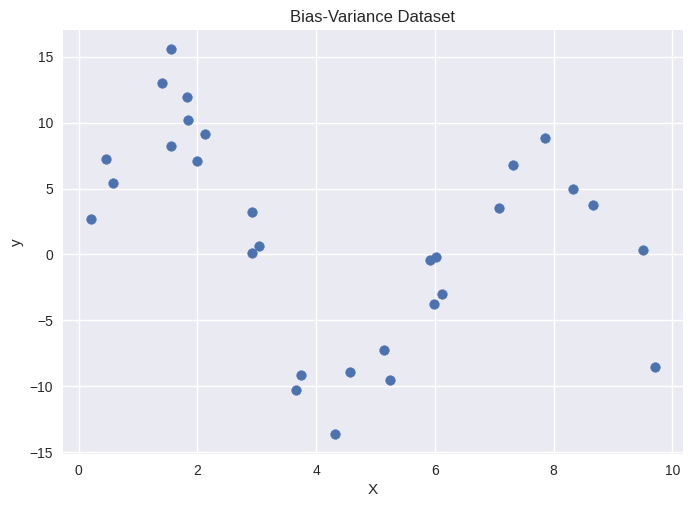

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Bias-Variance Dataset")
plt.show()

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

def create_model(degree):

    return Pipeline([
        ("poly", PolynomialFeatures(degree)),
        ("linear", LinearRegression())
    ])

In [ ]:
# Estimate Bias² and Variance
def simulate_bias_variance(degree, n_trials=100):

    # Common evaluation points
    X_test = np.linspace(0, 10, 200).reshape(-1, 1)

    # Store predictions from all models
    predictions = np.zeros((n_trials, len(X_test)))

    for i in range(n_trials):

        # Generate a new random dataset
        # X_train, y_train = generate_data()
        X_train, y_train = generate_data_strongerU()

        # Train model
        model = create_model(degree)
        model.fit(X_train, y_train)

        # Store predictions
        predictions[i] = model.predict(X_test)

    # Average prediction across all models
    avg_prediction = predictions.mean(axis=0)

    # True values
    y_true = true_function(X_test.ravel())

    # Bias²
    bias_squared = np.mean(
        (avg_prediction - y_true) ** 2
    )

    # Variance
    variance = np.mean(
        np.var(predictions, axis=0)
    )

    return bias_squared, variance

In [ ]:
print("Degree | Bias² | Variance | Total Error")
print("-" * 45)

degrees = range(1, 20)

bias_values = []
variance_values = []
total_errors = []

for degree in degrees:

    bias_sq, variance = simulate_bias_variance(
        degree,
        n_trials=100
    )

    total_error = bias_sq + variance

    bias_values.append(bias_sq)
    variance_values.append(variance)
    total_errors.append(total_error)

    print(
        f"{degree:>6} | "
        f"{bias_sq:>7.4f} | "
        f"{variance:>8.4f} | "
        f"{total_error:>10.4f}"
    )

Degree | Bias² | Variance | Total Error
---------------------------------------------
     1 | 44.1541 |   6.0327 |    50.1868
     2 | 36.9554 |  11.8966 |    48.8520
     3 | 41.0048 |  68.3902 |   109.3950
     4 |  4.8438 |  42.3027 |    47.1464
     5 |  9.7103 |  69.9389 |    79.6492
     6 |  6.3596 | 241.3142 |   247.6738
     7 |  7.9327 | 990.7618 |   998.6945
     8 | 13.5592 | 7089.0059 |  7102.5651
     9 | 676.2884 | 55317.9024 | 55994.1908
    10 | 79023.6180 | 7133989.4983 | 7213013.1163
    11 | 280379.2949 | 26441726.4242 | 26722105.7191
    12 | 2131802061.8066 | 204178669076.6482 | 206310471138.4547
    13 | 2815834.7916 | 135100527.2305 | 137916362.0221
    14 | 1522020.5284 | 163087947.7536 | 164609968.2820
    15 | 48633279.3156 | 49139750997.9982 | 49188384277.3138
    16 | 609446659560.6464 | 59807633372868.8125 | 60417080032429.4609
    17 | 11528417488988.8379 | 1138452767337004.2500 | 1149981184825993.0000
    18 | 7139890.0497 | 96784121376.0255 | 967912612

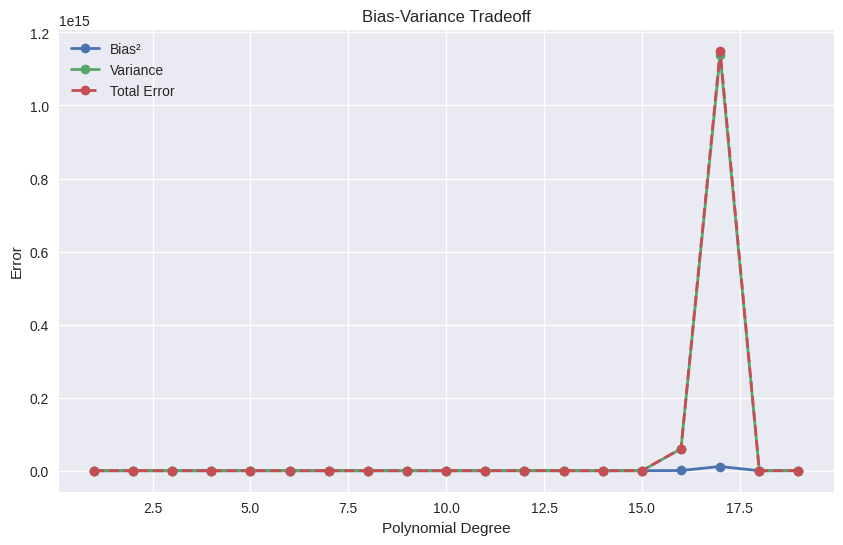

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    degrees,
    bias_values,
    marker="o",
    linewidth=2,
    label="Bias²"
)

plt.plot(
    degrees,
    variance_values,
    marker="o",
    linewidth=2,
    label="Variance"
)

plt.plot(
    degrees,
    total_errors,
    marker="o",
    linestyle="--",
    linewidth=2,
    label="Total Error"
)

plt.xlabel("Polynomial Degree")
plt.ylabel("Error")
plt.title("Bias-Variance Tradeoff")

plt.legend()
plt.grid(True)

plt.show()

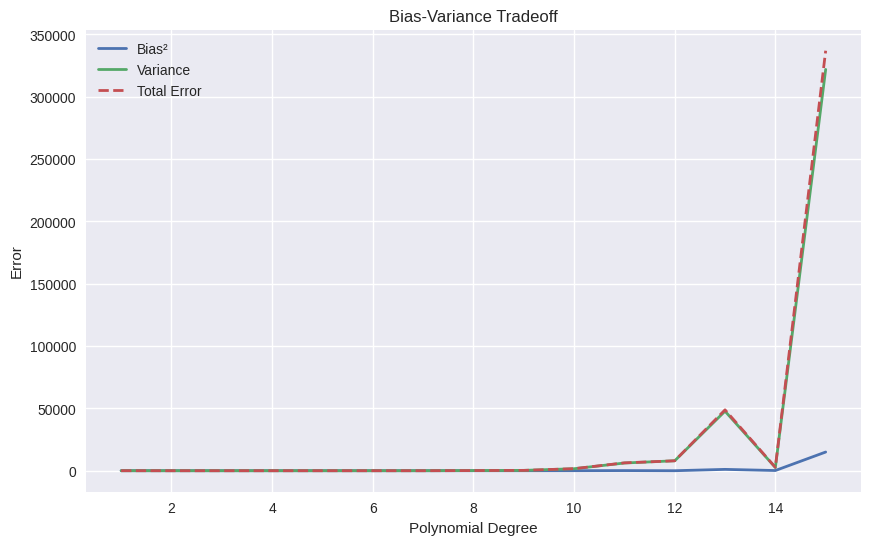

In [ ]:
# Plot the bias-variance tradeoff
plt.figure(figsize=(10, 6))

plt.plot(degrees, bias_values, label="Bias²", linewidth=2)
plt.plot(degrees, variance_values, label="Variance", linewidth=2)
plt.plot(degrees, total_errors, "--", label="Total Error", linewidth=2)

plt.xlabel("Polynomial Degree")
plt.ylabel("Error")
plt.title("Bias-Variance Tradeoff")

plt.legend()
plt.grid(True)
plt.show()

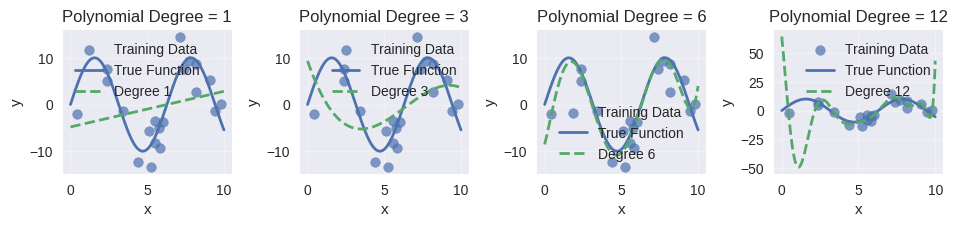

In [ ]:
# ==========================================================
# Visualize Underfitting vs Overfitting
# ==========================================================

# Degrees to compare
comparison_degrees = [1, 3, 6, 12]

# Generate one training dataset
X_train, y_train = generate_data()

# Smooth curve for plotting predictions
X_plot = np.linspace(0, 10, 500).reshape(-1, 1)

# True function values
y_true = true_function(X_plot.ravel())

plt.figure(figsize=(12, 8))

for i, degree in enumerate(comparison_degrees, start=1):

    # Train model
    model = create_polynomial_model(degree)
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_plot)

    # Create subplot
    plt.subplot(4, 5, i)

    # Training data
    plt.scatter(
        X_train,
        y_train,
        alpha=0.7,
        label="Training Data"
    )

    # True function
    plt.plot(
        X_plot,
        y_true,
        linewidth=2,
        label="True Function"
    )

    # Model prediction
    plt.plot(
        X_plot,
        y_pred,
        linewidth=2,
        linestyle="--",
        label=f"Degree {degree}"
    )

    plt.title(f"Polynomial Degree = {degree}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Degree | Bias²   | Variance | Total Error
---------------------------------------------
     1 |  44.081 |    3.425 |     47.506
     2 |  36.225 |    5.456 |     41.681
     3 |  34.137 |   14.022 |     48.159
     4 |   4.688 |    4.918 |      9.606
     5 |   4.365 |   17.587 |     21.952
     6 |   0.198 |   19.063 |     19.261
     7 |   0.603 |   32.632 |     33.235
     8 |   4.460 |  211.137 |    215.597


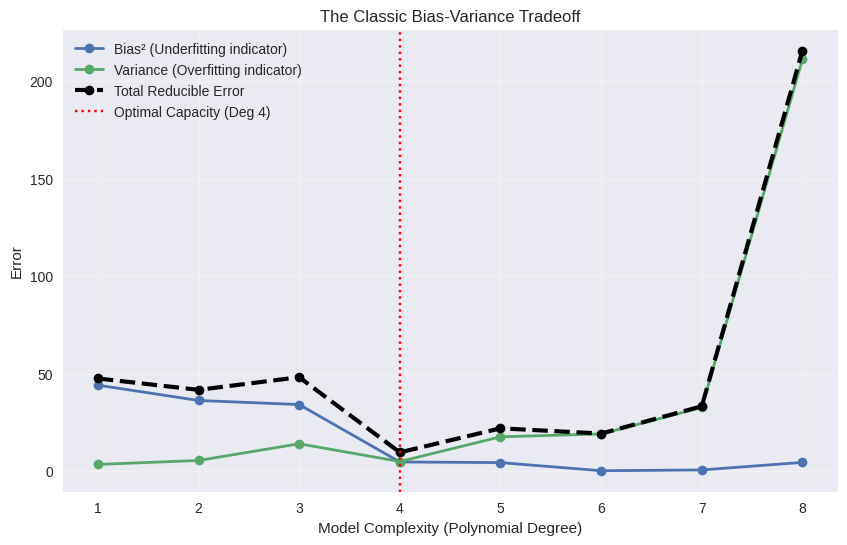

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression  # Updated from Ridge

# --------------------------------------------------
# Settings
# --------------------------------------------------

np.random.seed(42)

N_SAMPLES = 30    # Increased slightly to stabilize unregularized high degrees
NOISE_STD = 3     # Adjusted slightly for a cleaner signal-to-noise visual
N_TRIALS = 200

# --------------------------------------------------
# True function
# --------------------------------------------------

def true_function(x):
    return 10 * np.sin(x)

# --------------------------------------------------
# Generate random dataset
# --------------------------------------------------

def generate_data():

    X = np.random.uniform(0, 10, N_SAMPLES)

    y = (
        true_function(X)
        + np.random.normal(0, NOISE_STD, N_SAMPLES)
    )

    return X.reshape(-1, 1), y

# --------------------------------------------------
# Polynomial Linear Regression
# --------------------------------------------------

def create_model(degree):

    return Pipeline([
        ("scale", MinMaxScaler(feature_range=(-1, 1))),
        ("poly", PolynomialFeatures(degree=degree)),
        ("lr", LinearRegression())  # Swapped Ridge for OLS Linear Regression
    ])

# --------------------------------------------------
# Bias-Variance Simulation
# --------------------------------------------------

def simulate_bias_variance(degree):

    X_test = np.linspace(0, 10, 300).reshape(-1, 1)

    predictions = np.zeros((N_TRIALS, len(X_test)))

    for i in range(N_TRIALS):

        X_train, y_train = generate_data()

        model = create_model(degree)
        model.fit(X_train, y_train)

        predictions[i] = model.predict(X_test)

    # Average prediction
    avg_prediction = predictions.mean(axis=0)

    # True values
    y_true = true_function(X_test.ravel())

    # Bias²
    bias_squared = np.mean(
        (avg_prediction - y_true) ** 2
    )

    # Variance
    variance = np.mean(
        np.var(predictions, axis=0)
    )

    return bias_squared, variance

# --------------------------------------------------
# Run experiment
# --------------------------------------------------

# Capped at degree 8 to prevent float64 precision breakdown while showing full tradeoff
degrees = range(1, 9)

bias_values = []
variance_values = []
total_errors = []

print("Degree | Bias²   | Variance | Total Error")
print("-" * 45)

for degree in degrees:

    bias_sq, variance = simulate_bias_variance(degree)

    total_error = bias_sq + variance

    bias_values.append(bias_sq)
    variance_values.append(variance)
    total_errors.append(total_error)

    print(
        f"{degree:>6} | "
        f"{bias_sq:>7.3f} | "
        f"{variance:>8.3f} | "
        f"{total_error:>10.3f}"
    )

# --------------------------------------------------
# Plot
# --------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    degrees,
    bias_values,
    marker="o",
    linewidth=2,
    label="Bias² (Underfitting indicator)"
)

plt.plot(
    degrees,
    variance_values,
    marker="o",
    linewidth=2,
    label="Variance (Overfitting indicator)"
)

plt.plot(
    degrees,
    total_errors,
    marker="o",
    linestyle="--",
    linewidth=3,
    color="black",
    label="Total Reducible Error"
)

plt.xlabel("Model Complexity (Polynomial Degree)")
plt.ylabel("Error")
plt.title("The Classic Bias-Variance Tradeoff")

# Find the sweet spot (minimum total error) to draw a guide line
best_degree = degrees[np.argmin(total_errors)]
plt.axvline(x=best_degree, color='red', linestyle=':', label=f'Optimal Capacity (Deg {best_degree})')

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

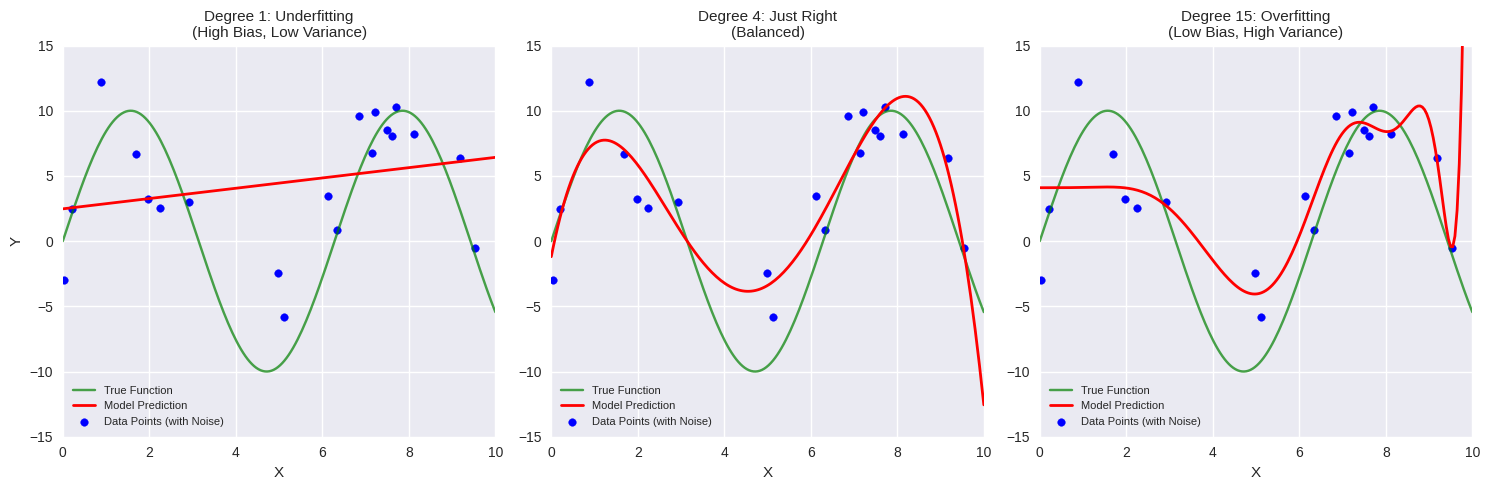

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# 1. Setup Random Seed and Data
np.random.seed(10)
N_SAMPLES = 20

# True pattern (A simple wave)
X = np.sort(np.random.uniform(0, 10, N_SAMPLES))
y_true = 10 * np.sin(X)
# Add some random noise
y_noisy = y_true + np.random.normal(0, 3, N_SAMPLES)

# Reshape for Scikit-Learn
X_plot = np.linspace(0, 10, 200).reshape(-1, 1)
X = X.reshape(-1, 1)

# 2. Define the 3 degrees we want to show students
degrees = [1, 4, 15]
titles = ['Degree 1: Underfitting\n(High Bias, Low Variance)',
          'Degree 4: Just Right\n(Balanced)',
          'Degree 15: Overfitting\n(Low Bias, High Variance)']

# 3. Plotting
plt.figure(figsize=(15, 5))

for i, degree in enumerate(degrees):
    ax = plt.subplot(1, 3, i + 1)

    # Create and fit the polynomial model
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X, y_noisy)

    # Predict over the entire range
    y_pred = model.predict(X_plot)

    # Draw the graphs
    plt.plot(X_plot, 10 * np.sin(X_plot), color='green', label="True Function", alpha=0.7)
    plt.plot(X_plot, y_pred, color='red', linewidth=2, label="Model Prediction")
    plt.scatter(X, y_noisy, color='blue', s=30, label="Data Points (with Noise)")

    plt.xlim(0, 10)
    plt.ylim(-15, 15)
    plt.title(titles[i], fontsize=11)
    if i == 0:
        plt.ylabel("Y")
    plt.xlabel("X")
    plt.legend(loc="lower left", fontsize=8)

plt.tight_layout()
plt.show()

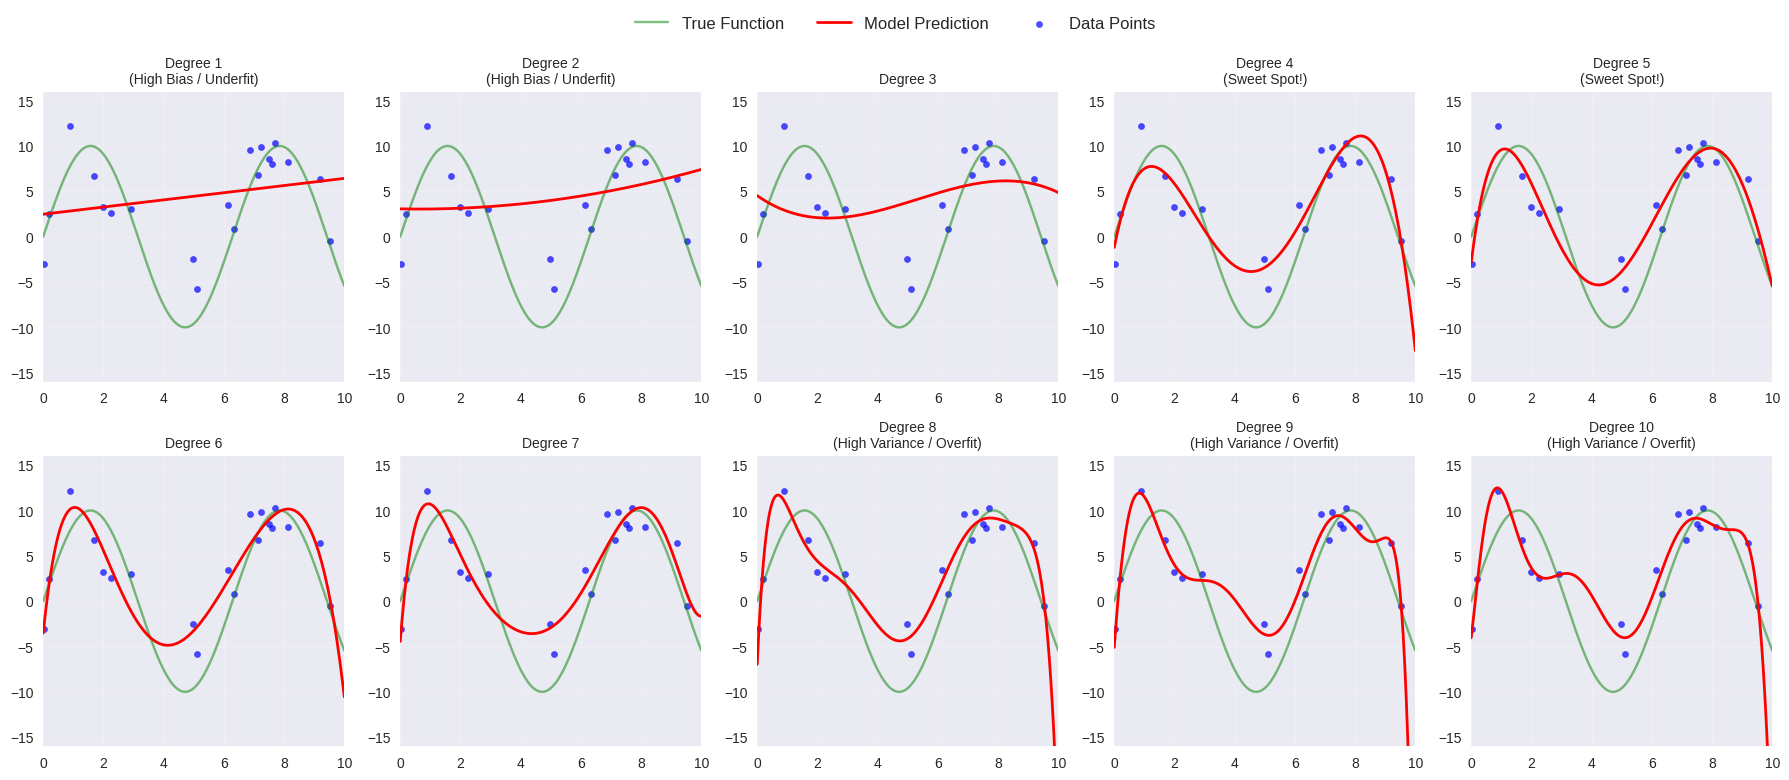

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# 1. Setup Random Seed and Data
np.random.seed(10)
N_SAMPLES = 20

# True pattern (A simple wave)
X = np.sort(np.random.uniform(0, 10, N_SAMPLES))
y_true = 10 * np.sin(X)
y_noisy = y_true + np.random.normal(0, 3, N_SAMPLES)

# Reshape for Scikit-Learn
X_plot = np.linspace(0, 10, 200).reshape(-1, 1)
X = X.reshape(-1, 1)

# 2. Set up a 2-row, 5-column grid for degrees 1 to 10
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()  # Flatten into a 1D array to loop easily

for i, degree in enumerate(range(1, 11)):
    ax = axes[i]

    # Create and fit the polynomial model
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X, y_noisy)

    # Predict over the entire range
    y_pred = model.predict(X_plot)

    # Draw the graphs on the current subplot (ax)
    ax.plot(X_plot, 10 * np.sin(X_plot), color='green', alpha=0.5, label="True Function" if i==0 else "")
    ax.plot(X_plot, y_pred, color='red', linewidth=2, label="Model Prediction" if i==0 else "")
    ax.scatter(X, y_noisy, color='blue', s=20, alpha=0.7, label="Data Points" if i==0 else "")

    ax.set_xlim(0, 10)
    ax.set_ylim(-16, 16)
    ax.grid(True, alpha=0.2)

    # Add educational annotations directly to the titles
    if degree <= 2:
        tag = "\n(High Bias / Underfit)"
    elif degree in [4, 5]:
        tag = "\n(Sweet Spot!)"
    elif degree >= 8:
        tag = "\n(High Variance / Overfit)"
    else:
        tag = ""

    ax.set_title(f"Degree {degree}{tag}", fontsize=10)

# Add a single legend for the whole figure to keep it clean
fig.legend(loc="upper center", bbox_to_anchor=(0.5, 0.98), ncol=3, fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()